# Figure 1 

In [1]:
options(warn=-1)

In [2]:
library_load <- suppressMessages(
    
    suppressWarnings(
        
        list(
        
            # Seurat 
            library(Seurat), 
            
            # miloR
            library(miloR), 
            library(ggbeeswarm), 
            
            # GLMM
            library(lmerTest),
            library(lme4), 
            library(emmeans), 
            
            # Diversity and PERMANOVA
            library(vegan), 
            library(pairwiseAdonis), 
             
            # Data 
            library(tidyverse), 
            library(data.table), 
            library(reactable), 

            # Plotting 
            library(ComplexHeatmap), 
            library(patchwork), 
            library(cowplot), 
            library(ggrepel), 
            library(egg), 
            library(ggh4x), 
            
            # Parallel 
            library(BiocParallel), 

            # Pyhton compatibility
            library(reticulate)

        )
    )
)

In [3]:
# Configure reticulate 
use_condaenv(condaenv="p.3.10.16-FD20250213HSCT", conda="/nobackup/peer/fdeckert/miniconda3/bin/conda", required=NULL)

In [4]:
random_seed <- 42
set.seed(random_seed)

In [5]:
# Set working directory to project root
setwd("/research/peer/fdeckert/FD20250213HSCT/")

In [6]:
# Plotting Theme
source("plotting_global.R")
ggplot2::theme_set(theme_global_set(size_select=4)) # From project global source()

In [7]:
# Source scripts 
source("bin/seurat_qc.R")
source("script/figure/bin/dp_feature.R")
source("script/figure/bin/line_plot.R")

# Import Seurat object

In [8]:
# All cells 
so <- readRDS("data/object/pp.rds")

# Blood immune cells
so_0 <- readRDS("data/object/pp_0.rds")

# Skin immune cells
so_1 <- readRDS("data/object/pp_1.rds")
so_1 <- so_1[, so_1$celltype_domain=="Immune~cells"]

# Skin non-immune cells 
so_2 <- readRDS("data/object/pp_1.rds")
so_2 <- so_2[, so_2$celltype_domain!="Immune~cells"]

# Skin all cells 
so_3 <- readRDS("data/object/pp_1.rds")

In [9]:
# Normalize 
so <- NormalizeData(so, assay="RNA", scale.factor=1e4)
so_0 <- NormalizeData(so_0, assay="RNA", scale.factor=1e4)
so_1 <- NormalizeData(so_1, assay="RNA", scale.factor=1e4)
so_2 <- NormalizeData(so_2, assay="RNA", scale.factor=1e4)
so_3 <- NormalizeData(so_3, assay="RNA", scale.factor=1e4)

Normalizing layer: counts

Normalizing layer: counts

Normalizing layer: counts

Normalizing layer: counts

Normalizing layer: counts



In [10]:
so@meta.data <- droplevels(so@meta.data)
so_0@meta.data <- droplevels(so_0@meta.data)
so_1@meta.data <- droplevels(so_1@meta.data)
so_2@meta.data <- droplevels(so_2@meta.data)
so_3@meta.data <- droplevels(so_3@meta.data)

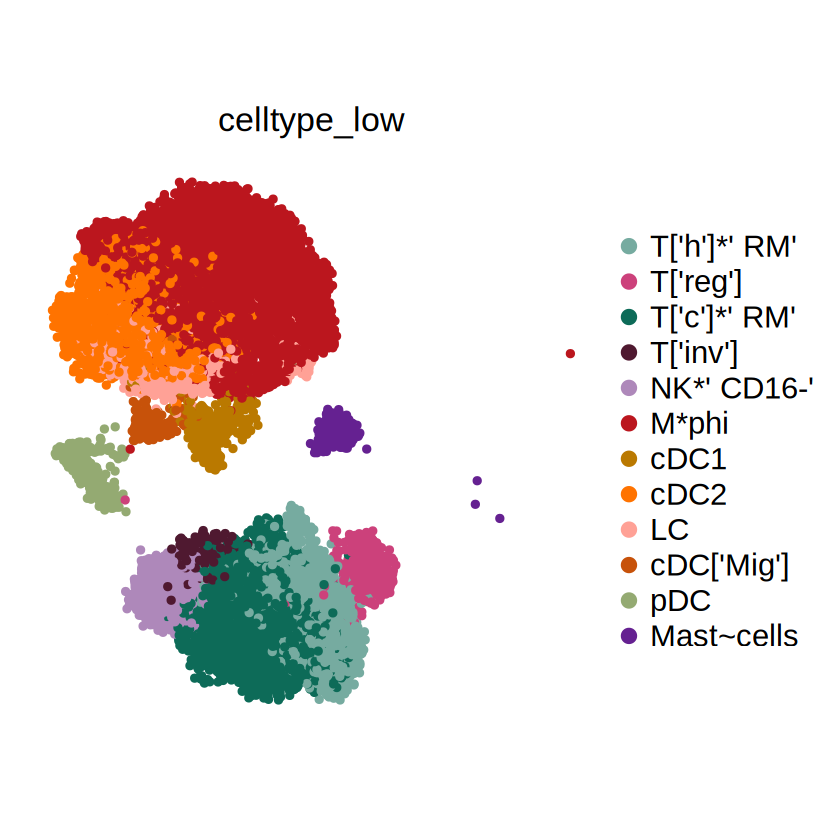

In [25]:
dplot(so_1, group_by = "celltype_low") + scale_color_manual(values = color$celltype_low_r)

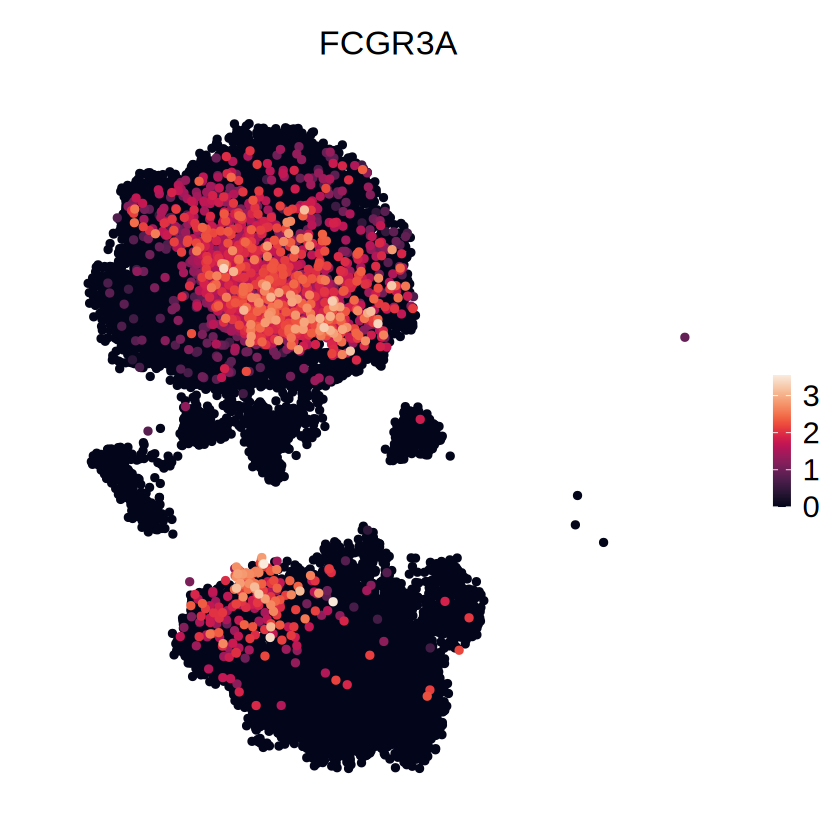

In [26]:
fplot(so_1, features = "FCGR3A", slot="data")

# Fine marker genes with celltype low labels 

In [11]:
# Genes and categories
genes <- read.csv("script/figure/figure_1/data/figure_1_dotplot_celltype_markers_fine_blood.csv")

In [12]:
dp_1 <- dp_feature(so_0, genes$gene, group_by="celltype_low", group_by_order=rev(levels(so_0$celltype_low)), split=NA, split_order=unique(genes$celltype), range_max=3, scale=TRUE) + 
    scale_y_discrete(labels=base::str2expression(rev(levels(so_0$celltype_low))))

`summarise()` has grouped output by 'celltype_low'. You can override using the
`.groups` argument.
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


In [13]:
pdf("result/figures/figure_1/dp_feature_celltype_markers_fine_blood.pdf", width=5.0, height=2.5)

set_height <- dp_1$data$celltype_low %>% unique() %>% length() * 2.5
set_width <- dp_1$data %>% dplyr::select(gene, split) %>% dplyr::distinct() %>% dplyr::group_by(split) %>% dplyr::summarise(n=n()) %>% dplyr::pull(n) * 2.5

gridExtra::grid.arrange(
    
    dp_1 + ggh4x::force_panelsizes(cols=unit(set_width, "mm"), rows=unit(set_height, "mm"))

)

dev.off()

pdf 
  2

In [14]:
# Genes and categories
genes <- read.csv("script/figure/figure_1/data/figure_1_dotplot_celltype_markers_fine_skin_immune.csv")

In [15]:
dp_1 <- dp_feature(so_1, genes$gene, group_by="celltype_low", group_by_order=rev(levels(so_1$celltype_low)), split=NA, split_order=unique(genes$celltype), range_max=3, scale=TRUE) + 
    scale_y_discrete(labels=base::str2expression(rev(levels(so_1$celltype_low))))

`summarise()` has grouped output by 'celltype_low'. You can override using the
`.groups` argument.
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


In [16]:
pdf("result/figures/figure_1/dp_feature_celltype_markers_fine_skin_immune.pdf", width=5.0, height=2.5)

set_height <- dp_1$data$celltype_low %>% unique() %>% length() * 2.5
set_width <- dp_1$data %>% dplyr::select(gene, split) %>% dplyr::distinct() %>% dplyr::group_by(split) %>% dplyr::summarise(n=n()) %>% dplyr::pull(n) * 2.5

gridExtra::grid.arrange(
    
    dp_1 + ggh4x::force_panelsizes(cols=unit(set_width, "mm"), total_height=unit(set_height, "mm"))

)

dev.off()

pdf 
  2

In [17]:
# Genes and categories
genes <- read.csv("script/figure/figure_1/data/figure_1_dotplot_celltype_markers_fine_skin_non_immune.csv")

In [18]:
dp_1 <- dp_feature(so_2, genes$gene, group_by="celltype_low", group_by_order=rev(levels(so_2$celltype_low)), split=NA, split_order=unique(genes$celltype), range_max=3, scale=TRUE) + 
    scale_y_discrete(labels=base::str2expression(rev(levels(so_2$celltype_low))))

`summarise()` has grouped output by 'celltype_low'. You can override using the
`.groups` argument.
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


In [19]:
pdf("result/figures/figure_1/dp_feature_celltype_markers_fine_skin_non_immune.pdf", width=5.0, height=2.5)

set_height <- dp_1$data$celltype_low %>% unique() %>% length() * 2.5
set_width <- dp_1$data %>% dplyr::select(gene, split) %>% dplyr::distinct() %>% dplyr::group_by(split) %>% dplyr::summarise(n=n()) %>% dplyr::pull(n) * 2.5

gridExtra::grid.arrange(
    
    dp_1 + ggh4x::force_panelsizes(cols=unit(set_width, "mm"), total_height=unit(set_height, "mm"))

)

dev.off()

pdf 
  2

# Broad marker genes with celltype high labels 

In [20]:
# Genes and categories
genes <- read.csv("script/figure/figure_1/data/figure_1_dotplot_celltype_markers_broad.csv")

In [21]:
dp_1 <- dp_feature(so, genes$gene, group_by="celltype_high", group_by_order=rev(levels(so$celltype_high)), split=NA, split_order=unique(genes$celltype), range_max=3, scale=TRUE) + 
    scale_y_discrete(labels=base::str2expression(rev(levels(so$celltype_high))))

`summarise()` has grouped output by 'celltype_high'. You can override using the
`.groups` argument.
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


In [22]:
pdf("result/figures/figure_1/dp_feature_celltype_markers_broad.pdf", width=5.0, height=2.5)

set_height <- dp_1$data$celltype_high %>% unique() %>% length() * 2.5
set_width <- dp_1$data %>% dplyr::select(gene, split) %>% dplyr::distinct() %>% dplyr::group_by(split) %>% dplyr::summarise(n=n()) %>% dplyr::pull(n) * 2.5

gridExtra::grid.arrange(
    
    dp_1 + ggh4x::force_panelsizes(cols=unit(set_width, "mm"), rows=unit(set_height, "mm"))

)

dev.off()

pdf 
  2

In [23]:
# Genes and categories
genes <- read.csv("script/figure/figure_1/data/figure_1_dotplot_celltype_markers_broad_blood.csv")

In [24]:
dp_1 <- dp_feature(so_0, genes$gene, group_by="celltype_high", group_by_order=rev(levels(so_0$celltype_high)), split=NA, split_order=unique(genes$celltype), range_max=3, scale=TRUE) + 
    scale_y_discrete(labels=base::str2expression(rev(levels(so_0$celltype_high))))

`summarise()` has grouped output by 'celltype_high'. You can override using the
`.groups` argument.
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


In [25]:
pdf("result/figures/figure_1/dp_feature_celltype_markers_broad_blood.pdf", width=5.0, height=2.5)

set_height <- dp_1$data$celltype_high %>% unique() %>% length() * 2.5
set_width <- dp_1$data %>% dplyr::select(gene, split) %>% dplyr::distinct() %>% dplyr::group_by(split) %>% dplyr::summarise(n=n()) %>% dplyr::pull(n) * 2.5

gridExtra::grid.arrange(
    
    dp_1 + ggh4x::force_panelsizes(cols=unit(set_width, "mm"), total_height=unit(set_height, "mm"))

)

dev.off()

pdf 
  2

In [26]:
# Genes and categories
genes <- read.csv("script/figure/figure_1/data/figure_1_dotplot_celltype_markers_broad_skin.csv")

In [27]:
dp_1 <- dp_feature(so_3, genes$gene, group_by="celltype_high", group_by_order=rev(levels(so_3$celltype_high)), split=NA, split_order=unique(genes$celltype), range_max=3, scale=TRUE) + 
    scale_y_discrete(labels=base::str2expression(rev(levels(so_3$celltype_high))))

`summarise()` has grouped output by 'celltype_high'. You can override using the
`.groups` argument.
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


In [28]:
pdf("result/figures/figure_1/dp_feature_celltype_markers_broad_skin.pdf", width=5.0, height=2.5)

set_height <- dp_1$data$celltype_high %>% unique() %>% length() * 2.5
set_width <- dp_1$data %>% dplyr::select(gene, split) %>% dplyr::distinct() %>% dplyr::group_by(split) %>% dplyr::summarise(n=n()) %>% dplyr::pull(n) * 2.5

gridExtra::grid.arrange(
    
    dp_1 + ggh4x::force_panelsizes(cols=unit(set_width, "mm"), total_height=unit(set_height, "mm"))

)

dev.off()

pdf 
  2

# UMAP 

## Cell type low

In [29]:
pdf("result/figures/figure_1/umap_celltype_low.pdf", width=10, height=3)

dplot_1 <- dplot(so, reduction="umap", group_by="celltype_low", alpha=1, pt_size=0.5, size_select=4, shuffle=TRUE) + 
    ggtitle("Cell type leiden") + 
    scale_color_manual(values=color$celltype_low_r, na.value="grey50", labels=base::str2expression(levels(so$celltype_low))) + 
    guides(color=guide_legend(ncol=2, override.aes=list(alpha=1, size=1.5), keywidth=0, keyheight=0.25, default.unit="cm")) + 
    theme(
    
        legend.text.align=0
    
    ) 

gridExtra::grid.arrange(
    
    dplot_1 %>% egg::set_panel_size(., width=unit(5, "cm"), height=unit(5, "cm"))

)

dev.off()

pdf 
  2

In [30]:
pdf("result/figures/figure_1/umap_celltype_low_blood.pdf", width=10, height=3)

dplot_1 <- dplot(so_0, reduction="umap", group_by="celltype_low", alpha=1, pt_size=0.5, size_select=4, shuffle=TRUE) + 
    ggtitle("Cell type leiden") + 
    scale_color_manual(values=color$celltype_low_r, na.value="grey50", labels=base::str2expression(levels(so_0$celltype_low))) + 
    guides(color=guide_legend(ncol=2, override.aes=list(alpha=1, size=1.5), keywidth=0, keyheight=0.25, default.unit="cm")) + 
    theme(
    
        legend.text.align=0
    
    ) 

gridExtra::grid.arrange(
    
    dplot_1 %>% egg::set_panel_size(., width=unit(5, "cm"), height=unit(5, "cm"))

)

dev.off()

pdf 
  2

In [31]:
pdf("result/figures/figure_1/umap_celltype_low_skin.pdf", width=10, height=3)

dplot_1 <- dplot(so_3, reduction="umap", group_by="celltype_low", alpha=1, pt_size=0.5, size_select=4, shuffle=TRUE) + 
    ggtitle("Cell type leiden") + 
    scale_color_manual(values=color$celltype_low_r, na.value="grey50", labels=base::str2expression(levels(so_3$celltype_low))) + 
    guides(color=guide_legend(ncol=2, override.aes=list(alpha=1, size=1.5), keywidth=0, keyheight=0.25, default.unit="cm")) + 
    theme(
    
        legend.text.align=0
    
    ) 

gridExtra::grid.arrange(
    
    dplot_1 %>% egg::set_panel_size(., width=unit(5, "cm"), height=unit(5, "cm"))

)

dev.off()

pdf 
  2

## Patient ID

In [32]:
pdf("result/figures/figure_1/umap_patient_id.pdf", width=10, height=3)

dplot_2 <- dplot(so, reduction="umap", group_by="patient_id", alpha=1, pt_size=0.5, size_select=4, shuffle=TRUE) + ggtitle("Patient ID") + 
    scale_color_manual(values=color$patient_id, na.value="grey50") + 
    guides(color=guide_legend(ncol=1, override.aes=list(alpha=1, size=1.5), keywidth=0, keyheight=0.25, default.unit="cm"))

gridExtra::grid.arrange(
    
    dplot_2 %>% egg::set_panel_size(., width=unit(5, "cm"), height=unit(5, "cm"))

)

dev.off()

pdf 
  2

In [33]:
pdf("result/figures/figure_1/umap_patient_id_blood.pdf", width=10, height=3)

dplot_2 <- dplot(so_0, reduction="umap", group_by="patient_id", alpha=1, pt_size=0.5, size_select=4, shuffle=TRUE) + ggtitle("Patient ID") + 
    scale_color_manual(values=color$patient_id, na.value="grey50") + 
    guides(color=guide_legend(ncol=1, override.aes=list(alpha=1, size=1.5), keywidth=0, keyheight=0.25, default.unit="cm"))

gridExtra::grid.arrange(
    
    dplot_2 %>% egg::set_panel_size(., width=unit(5, "cm"), height=unit(5, "cm"))

)

dev.off()

pdf 
  2

In [34]:
pdf("result/figures/figure_1/umap_patient_id_skin.pdf", width=10, height=3)

dplot_2 <- dplot(so_3, reduction="umap", group_by="patient_id", alpha=1, pt_size=0.5, size_select=4, shuffle=TRUE) + ggtitle("Patient ID") + 
    scale_color_manual(values=color$patient_id, na.value="grey50") + 
    guides(color=guide_legend(ncol=1, override.aes=list(alpha=1, size=1.5), keywidth=0, keyheight=0.25, default.unit="cm"))

gridExtra::grid.arrange(
    
    dplot_2 %>% egg::set_panel_size(., width=unit(5, "cm"), height=unit(5, "cm"))

)

dev.off()

pdf 
  2

## HTO demux class

In [35]:
pdf("result/figures/figure_1/umap_hto_demux_class.pdf", width=10, height=3)

dplot_3 <- dplot(so, reduction="umap", group_by="hto_demux_class", alpha=1, pt_size=0.5, size_select=4, shuffle=TRUE) + ggtitle("Tissue") + 
    scale_color_manual(values=color$hto_demux_class, na.value="grey50") + 
    guides(color=guide_legend(ncol=1, override.aes=list(alpha=1, size=1.5), keywidth=0, keyheight=0.25, default.unit="cm"))

gridExtra::grid.arrange(
    
    dplot_3 %>% egg::set_panel_size(., width=unit(5, "cm"), height=unit(5, "cm"))

)

dev.off()

pdf 
  2

In [36]:
pdf("result/figures/figure_1/umap_hto_demux_class_blood.pdf", width=10, height=3)

dplot_3 <- dplot(so_0, reduction="umap", group_by="hto_demux_class", alpha=1, pt_size=0.5, size_select=4, shuffle=TRUE) + ggtitle("Tissue") + 
    scale_color_manual(values=color$hto_demux_class, na.value="grey50") + 
    guides(color=guide_legend(ncol=1, override.aes=list(alpha=1, size=1.5), keywidth=0, keyheight=0.25, default.unit="cm"))

gridExtra::grid.arrange(
    
    dplot_3 %>% egg::set_panel_size(., width=unit(5, "cm"), height=unit(5, "cm"))

)

dev.off()

pdf 
  2

In [37]:
pdf("result/figures/figure_1/umap_hto_demux_class_skin.pdf", width=10, height=3)

dplot_3 <- dplot(so_3, reduction="umap", group_by="hto_demux_class", alpha=1, pt_size=0.5, size_select=4, shuffle=TRUE) + ggtitle("Tissue") + 
    scale_color_manual(values=color$hto_demux_class, na.value="grey50") + 
    guides(color=guide_legend(ncol=1, override.aes=list(alpha=1, size=1.5), keywidth=0, keyheight=0.25, default.unit="cm"))

gridExtra::grid.arrange(
    
    dplot_3 %>% egg::set_panel_size(., width=unit(5, "cm"), height=unit(5, "cm"))

)

dev.off()

pdf 
  2

## Genotype class

In [38]:
pdf("result/figures/figure_1/umap_genotype_class.pdf", width=10, height=3)

dplot_4 <- dplot(subset(so, subset=genotype_class %in% c("Host", "Donor", "unassigned", "doublet")), reduction="umap", group_by="genotype_class", alpha=1, pt_size=0.5, size_select=4, shuffle=TRUE) + ggtitle("Genotype") + 
    scale_color_manual(values=color$genotype_class, na.value="grey50") + 
    guides(color=guide_legend(ncol=1, override.aes=list(alpha=1, size=1.5), keywidth=0, keyheight=0.25, default.unit="cm"))

gridExtra::grid.arrange(
    
    dplot_4 %>% egg::set_panel_size(., width=unit(5, "cm"), height=unit(5, "cm"))

)

dev.off()

pdf 
  2

In [39]:
pdf("result/figures/figure_1/umap_genotype_class_blood.pdf", width=10, height=3)

dplot_4 <- dplot(subset(so_0, subset=genotype_class %in% c("Host", "Donor", "unassigned", "doublet")), reduction="umap", group_by="genotype_class", alpha=1, pt_size=0.5, size_select=4, shuffle=TRUE) + ggtitle("Genotype") + 
    scale_color_manual(values=color$genotype_class, na.value="grey50") + 
    guides(color=guide_legend(ncol=1, override.aes=list(alpha=1, size=1.5), keywidth=0, keyheight=0.25, default.unit="cm"))

gridExtra::grid.arrange(
    
    dplot_4 %>% egg::set_panel_size(., width=unit(5, "cm"), height=unit(5, "cm"))

)

dev.off()

pdf 
  2

In [40]:
pdf("result/figures/figure_1/umap_genotype_class_skin.pdf", width=10, height=3)

dplot_4 <- dplot(subset(so_3, subset=genotype_class %in% c("Host", "Donor", "unassigned", "doublet")), reduction="umap", group_by="genotype_class", alpha=1, pt_size=0.5, size_select=4, shuffle=TRUE) + ggtitle("Genotype") + 
    scale_color_manual(values=color$genotype_class, na.value="grey50") + 
    guides(color=guide_legend(ncol=1, override.aes=list(alpha=1, size=1.5), keywidth=0, keyheight=0.25, default.unit="cm"))

gridExtra::grid.arrange(
    
    dplot_4 %>% egg::set_panel_size(., width=unit(5, "cm"), height=unit(5, "cm"))

)

dev.off()

pdf 
  2

# Patient distribution within broad cell types 

In [41]:
pdf("result/figures/figure_1/bp_patient_id_celltype_high.pdf", width=3, height=2)

bp_1 <- ggplot(so@meta.data, aes(x=celltype_high, fill=patient_id)) + 
    
    geom_bar(position="fill", color="black", size=0.1, width=0.8) + 
    scale_y_continuous(expand=c(0.01, 0.01)) +

    scale_fill_manual(values=color$patient_id) + 
    scale_x_discrete(labels=base::str2expression(levels(so$celltype_high))) + 
    ggtitle("Patient composition") + xlab("") + ylab("Patient ID [ratio]") + 
    theme(axis.text.x=element_text(angle=90, vjust=0.5, hjust=1)) + 
    guides(fill=guide_legend(ncol=1, override.aes=list(alpha=1, size=1.5), keywidth=0.25, keyheight=0.25, default.unit="cm"))

gridExtra::grid.arrange(
    
    bp_1 %>% egg::set_panel_size(., width=unit(12*2.5, "mm"), height=unit(2.5, "cm"))

) 

dev.off()

pdf 
  2

# Genotype line plots 

## Cell type percentage Host vs Donor 

In [42]:
data <- so@meta.data %>% 

    # Select relevant entries 
    dplyr::select(celltype_domain, patient_id, hto_demux_class, time_point, genotype_class) %>% droplevels() %>%
    
    # Make domain leiden labels
    dplyr::mutate(celltype_domain=ifelse(celltype_domain=="Immune~cells", "CD45+", "CD45-")) %>% 
    dplyr::mutate(celltype_domain=paste0(hto_demux_class, "\n(", celltype_domain, ")")) %>%
    dplyr::mutate(celltype_domain=factor(celltype_domain, levels=c("Blood\n(CD45+)", "Skin\n(CD45+)", "Skin\n(CD45-)"))) %>% 
    
    # Cell count total for hto demux domain labels 
    dplyr::group_by(celltype_domain, patient_id, hto_demux_class, time_point) %>% 
    dplyr::mutate(cell_count_total=n()) %>%
    
    # Cell count for genotype class
    dplyr::group_by(genotype_class, .add=TRUE) %>% 
    dplyr::mutate(cell_count_gc=n()) %>%
    
    # Ratio 
    dplyr::mutate(ratio_gc=cell_count_gc/cell_count_total) %>% 
    
    # Clean up data 
    dplyr::select(-cell_count_total, -cell_count_gc) %>% 
    dplyr::distinct() %>% 

    # Fill missing genotype ratios 
    group_by(across(setdiff(group_vars(.), 'genotype_class'))) %>% 
    tidyr::complete(., genotype_class, fill=list(ratio_gc=0)) %>% 

    # Make percentage 
    dplyr::mutate(perc_gc=100*ratio_gc) %>% 

    # Ungroup 
    dplyr::ungroup()

In [43]:
data <- dplyr::group_by(data, time_point, celltype_domain, genotype_class) %>% 
    dplyr::mutate(mean=mean(perc_gc), sd=sd(perc_gc), n=length(unique(patient_id)), sem=sd/sqrt(n), ymin=ifelse(mean-sem<0, 0, mean-sem), ymax=ifelse(mean+sem>100, 100, mean+sem)) %>%
    dplyr::select(celltype_domain, time_point, genotype_class, mean, ymin, ymax) %>% dplyr::distinct()

In [44]:
pdf("result/figures/figure_1/line_plot_genotype_class_ratio.pdf", width=3, height=2)

lp <- lp_time_point(data, title="", ylab="Genotype~ratio", filter_errorbar=c("Host", "Donor")) + facet_grid(~celltype_domain) + scale_y_continuous(breaks=c(0, 50, 100), labels=c("0", "50", "100"))

set_height <- 2.5
set_width <- rep(4, 16) * 4.0

gridExtra::grid.arrange(
    
    lp + ggh4x::force_panelsizes(cols=unit(set_width, "mm"), total_height=unit(set_height, "cm"))

)

dev.off()

pdf 
  2

## Cell type diversity 

In [45]:
data <- so@meta.data %>%

    # Select relevant entries 
    dplyr::select(celltype_low, celltype_domain, patient_id, hto_demux_class, time_point, genotype_class) %>% droplevels() %>% 
    
    # Make domain leiden labels
    dplyr::mutate(celltype_domain=ifelse(celltype_domain=="Immune~cells", "CD45+", "CD45-")) %>% 
    dplyr::mutate(celltype_domain=paste0(hto_demux_class, "\n(", celltype_domain, ")")) %>%
    dplyr::mutate(celltype_domain=factor(celltype_domain, levels=c("Blood\n(CD45+)", "Skin\n(CD45+)", "Skin\n(CD45-)"))) %>% 
    
    # Cell count total for genotype class within groups
    dplyr::group_by(celltype_low, celltype_domain, patient_id, time_point, genotype_class) %>%
    dplyr::summarise(cell_count_gc=n()) %>% dplyr::group_by(genotype_class, .add=TRUE) %>% # I don't know why but summarising delets the genotype_class grouping variable 

    # Filter out singeltons 
    dplyr::filter(cell_count_gc>1) %>% 
    
    # Compute richness 
    group_by(across(setdiff(group_vars(.), 'celltype_low'))) %>% 
    dplyr::summarise(richness=n()) %>% 

    # Fill missing genotype ratios 
    group_by(across(setdiff(group_vars(.), 'genotype_class'))) %>% 
    tidyr::complete(., genotype_class, fill=list(richness=0)) %>% 

    # Ungroup 
    dplyr::ungroup()

`summarise()` has grouped output by 'celltype_low', 'celltype_domain',
'patient_id', 'time_point'. You can override using the `.groups` argument.
`summarise()` has grouped output by 'celltype_domain', 'patient_id',
'time_point'. You can override using the `.groups` argument.


In [46]:
data <- dplyr::group_by(data, celltype_domain, time_point, genotype_class) %>% 
    dplyr::mutate(mean=mean(richness), sd=sd(richness), n=length(unique(patient_id)), sem=sd/sqrt(n), ymin=ifelse(mean-sem<0, 0, mean-sem), ymax=mean+sem) %>%
    dplyr::select(celltype_domain, time_point, genotype_class, mean, ymin, ymax) %>% dplyr::distinct()

In [47]:
pdf("result/figures/figure_1/line_plot_genotype_class_richness.pdf", width=3, height=2)

lp <- lp_time_point(data, title="", ylab="Richness") + facet_grid(~celltype_domain) 

set_height <- 2.5
set_width <- rep(4, 16) * 4.0

gridExtra::grid.arrange(
    
    lp + ggh4x::force_panelsizes(cols=unit(set_width, "mm"), total_height=unit(set_height, "cm"))

)

dev.off()

pdf 
  2

# Cell type composition 

## Cell types per patient ID 

In [48]:
cell_count <- so@meta.data %>% 

    # Make domain leiden labels
    dplyr::mutate(celltype_domain=ifelse(celltype_domain=="Immune~cells", "CD45+", "CD45-")) %>% 
    dplyr::mutate(celltype_domain=paste0(hto_demux_class, "\n(", celltype_domain, ")")) %>%
    dplyr::mutate(celltype_domain=factor(celltype_domain, levels=c("Blood\n(CD45+)", "Skin\n(CD45+)", "Skin\n(CD45-)"))) %>% 

    # Mutate patient labels 
    dplyr::mutate(patient_id=factor(gsub("Patient_", "P", patient_id), levels=paste0("P", 1:12))) %>% 
    
    # Count cell types
    dplyr::group_by(patient_id, time_point, celltype_domain, celltype_low) %>%  
    dplyr::summarise(cell_count=n()) %>% dplyr::ungroup() %>% 

    dplyr::mutate(sample_id=paste0(patient_id, "_", time_point, "_", celltype_domain)) %>% 

    dplyr::select(sample_id, cell_count, celltype_low) %>%
    
    tidyr::pivot_wider(., names_from=sample_id, values_from=cell_count, values_fill=0) %>% column_to_rownames("celltype_low")

`summarise()` has grouped output by 'patient_id', 'time_point',
'celltype_domain'. You can override using the `.groups` argument.


In [49]:
celltype_low_non_hhematopoetic <- so@meta.data %>% dplyr::select(celltype_domain, celltype_low) %>% dplyr::filter(celltype_domain=="'Non-hematopoetic'") %>% dplyr::pull(celltype_low) %>% unique()

In [77]:
cell_count <- so@meta.data %>% 

    # Mutate patient labels 
    dplyr::mutate(patient_id=factor(gsub("Patient_", "P", patient_id), levels=paste0("P", 1:12))) %>% 
    
    # Count cell types
    dplyr::group_by(patient_id, time_point, celltype_low, hto_demux_class, digestion_protocol) %>%  
    dplyr::summarise(cell_count=n()) %>% dplyr::ungroup() %>% 

    dplyr::mutate(sample_id=paste0(patient_id, "_", time_point, "_", hto_demux_class, "_", digestion_protocol)) %>% 

    dplyr::select(sample_id, cell_count, celltype_low) %>%
    
    tidyr::pivot_wider(., names_from=sample_id, values_from=cell_count, values_fill=0) %>% column_to_rownames("celltype_low")

cell_count <- lapply(c("Blood", "Skin"), function(i) {

    cnt <- cell_count[, grep(i, colnames(cell_count), fixed=TRUE)]
    cnt <- cnt[rowSums(cnt)>0, ]
    cnt <- as.matrix(cnt)

    nrm <- log2(cnt)
    
    nrm <- as.data.frame(nrm) %>%
        tibble::rownames_to_column("celltype_low") %>%
        tidyr::pivot_longer(-celltype_low, names_to="sample_id", values_to="cell_count") %>% 
        tidyr::separate(sample_id, into=c("patient_id", "time_point", "hto_demux_class", "digestion_protocol"), sep = "_") %>% 
        dplyr::mutate(patient_id=factor(patient_id, levels=paste0("P", 1:12)), time_point=factor(time_point, levels=names(color$time_point)), celltype_low=factor(celltype_low, levels=names(color$celltype_low_r))) %>% 
        dplyr::mutate(
            
            celltype_domain=ifelse(hto_demux_class=="Blood", "Blood\n(CD45+)", ifelse(celltype_low %in% celltype_low_non_hhematopoetic, "Skin\n(CD45-)", "Skin\n(CD45+)"))
        
        )
    

    return(nrm)
    
}
      )

`summarise()` has grouped output by 'patient_id', 'time_point', 'celltype_low',
'hto_demux_class'. You can override using the `.groups` argument.


In [78]:
cell_count <- do.call(rbind, cell_count) 

In [79]:
label <- names(color$celltype_low_r)

In [80]:
pdf("result/figures/figure_1/bp_celltype_low_patient_id_blood_immune_counts.pdf", width=5, height=6)

data_1 <- cell_count[cell_count$celltype_domain=="Blood\n(CD45+)", ] %>% na.omit() %>% droplevels()
label_1 <- label[label %in% data_1$celltype_low]

bp_1 <- ggplot(data_1, aes(x=patient_id, y=cell_count, fill=celltype_low)) + 
    
    geom_bar(stat="identity", color="black", size=0.1, width=0.8) + 
    scale_y_continuous(expand=c(0.01, 0.01)) +
    ylab("Counts") + xlab("") +
    
    facet_grid(celltype_domain~time_point, space="free", scales="free_x") + 
    scale_fill_manual(values=color$celltype_low_r, labels=base::str2expression(label_1)) + 
    theme(axis.text.x=element_text(angle=90, vjust=0.5, hjust=1)) + 
    guides(fill=guide_legend(ncol=1, override.aes=list(alpha=1, size=1.5), keywidth=0, keyheight=0.1, default.unit="cm", title=NULL))

set_height <- 2.5
set_width <- c(7, 4, 6, 4, 6) * 2.5

gridExtra::grid.arrange(
    
    bp_1 + ggh4x::force_panelsizes(cols=unit(set_width, "mm"), total_height=unit(set_height, "cm"))

)

dev.off()

pdf 
  2

In [81]:
pdf("result/figures/figure_1/bp_celltype_low_patient_id_skin_immune_counts.pdf", width=5, height=6)

data_2 <- cell_count[cell_count$celltype_domain=="Skin\n(CD45+)", ] %>% na.omit() %>% droplevels()
label_2 <- label[label %in% data_2$celltype_low]

bp_2 <- ggplot(data_2, aes(x=patient_id, y=cell_count, fill=celltype_low)) + 
    
    geom_bar(stat="identity", color="black", size=0.1, width=0.8) + 
    scale_y_continuous(expand=c(0.01, 0.01)) +
    ylab("Counts") + xlab("") +

    facet_grid(celltype_domain~time_point, space="free", scales="free_x") + 
    scale_fill_manual(values=color$celltype_low_r, labels=base::str2expression(label_2)) + 
    theme(axis.text.x=element_text(angle=90, vjust=0.5, hjust=1)) + 
    guides(fill=guide_legend(ncol=1, override.aes=list(alpha=1, size=1.5), keywidth=0, keyheight=0.1, default.unit="cm", title=NULL))

set_height <- 2.5
set_width <- c(7, 4, 6, 4, 6) * 2.5

gridExtra::grid.arrange(
    
    bp_2 + ggh4x::force_panelsizes(cols=unit(set_width, "mm"), total_height=unit(set_height, "cm"))

)

dev.off()

pdf 
  2

In [82]:
pdf("result/figures/figure_1/bp_celltype_low_patient_id_skin_none_immune_counts.pdf", width=5, height=6)

data_3 <- cell_count[cell_count$celltype_domain=="Skin\n(CD45-)", ] %>% na.omit() %>% droplevels()
label_3 <- label[label %in% data_3$celltype_low]


bp_3 <- ggplot(data_3, aes(x=patient_id, y=cell_count, fill=celltype_low)) + 
    
    geom_bar(stat="identity", color="black", size=0.1, width=0.8) + 
    scale_y_continuous(expand=c(0.01, 0.01)) +
    ylab("Counts") + xlab("") +

    facet_grid(celltype_domain~time_point, space="free", scales="free_x") + 
    scale_fill_manual(values=color$celltype_low_r, labels=base::str2expression(label_3)) + 
    theme(axis.text.x=element_text(angle=90, vjust=0.5, hjust=1)) + 
    guides(fill=guide_legend(ncol=1, override.aes=list(alpha=1, size=1.5), keywidth=0, keyheight=0.1, default.unit="cm", title=NULL))

set_height <- 2.5
set_width <- c(7, 4, 6, 4, 6) * 2.5

gridExtra::grid.arrange(
    
    bp_3 + ggh4x::force_panelsizes(cols=unit(set_width, "mm"), total_height=unit(set_height, "cm"))

)

dev.off()

pdf 
  2

# Vireo genotype

In [56]:
vireo <- read.csv("result/genotype/genotype.csv", row.names=1) 

In [57]:
mat <- dplyr::left_join(dplyr::select(so@meta.data, cell_id, time_point, celltype_domain), tibble::rownames_to_column(vireo, "cell_id"), by=join_by(cell_id))%>% 
    dplyr::mutate(genotype_class=factor(genotype_class, levels=names(color$genotype_class))) %>% 
    dplyr::mutate(time_point=factor(time_point, levels=names(color$time_point))) %>% 
    dplyr::mutate(celltype_domain=ifelse(celltype_domain=="Immune~cells", "CD45+", "CD45-")) %>%
    dplyr::mutate(celltype_domain=factor(celltype_domain, levels=c("CD45\u002D", "CD45\u002B"))) 

In [58]:
mat <- data.frame(

    genotype_class=rep(mat$genotype_class, 2), 
    category=c(mat$time_point, mat$celltype_domain), 
    type=factor(rep(c("Time point", "Cell type"), each=nrow(mat)), levels=c("Time point", "Cell type"))

)   

In [59]:
p_1 <- ggplot(mat, aes(x=category, fill=genotype_class)) + 

    geom_bar(position="fill", color="black", size=0.1, width=0.8) + 
    scale_y_continuous(expand=c(0.01, 0.01)) +

    scale_fill_manual(values=color$genotype) + 
    facet_grid(~type, scales="free", space="free") + 
    theme(axis.text.x=element_text(angle=45, vjust=1, hjust=1))  +  
    guides(fill=guide_legend(ncol=1, override.aes=list(alpha=1, size=2), keywidth=0.2, keyheight=0.2, default.unit="cm"))

In [60]:
pdf("result/figures/figure_1/bp_genotype.pdf", width=2.5, height=2)

set_height <- 2.5
set_width <- c(4, 2) * 4.0

gridExtra::grid.arrange(
    
    p_1 + ggh4x::force_panelsizes(cols=unit(set_width, "mm"), total_height=unit(set_height, "cm"))

)

dev.off()

pdf 
  2

# Variant SNPs

In [61]:
gt_vep <- read.csv("result/genotype/gt_vep.csv", row.names=1)

## Discriminate variant heatmap 

In [62]:
mat <- dplyr::filter(gt_vep,  VARIANT, ((GT_DONOR0=="1/1" & GT_DONOR1=="0/0") | (GT_DONOR0=="0/0" & GT_DONOR1=="1/1")), PATIENT_ID!="Patient_2") %>% 
    
    # Get genotype likelihood and filter for highly confident hits 
    dplyr::mutate(LP0=sapply(strsplit(DONOR0, ":"), "[", 4), LP1=sapply(strsplit(DONOR1, ":"), "[", 4)) %>% 
    dplyr::mutate(GTLP0=ifelse(GT_DONOR0=="1/1", sapply(strsplit(LP0, ","), "[", 3), sapply(strsplit(LP0, ","), "[", 1)), GTLP1=ifelse(GT_DONOR1=="1/1", sapply(strsplit(LP1, ","), "[", 3), sapply(strsplit(LP1, ","), "[", 1))) %>% 
    dplyr::filter(GTLP0==0 & GTLP1==0) %>%
    
    # Compute MAF 
    dplyr::mutate(MAF0=AD_DONOR0/DP_DONOR0, MAF1=AD_DONOR1/DP_DONOR1) %>%
    
    # Make unique IDs for patients for subsetting 
    dplyr::mutate(ID=paste(SYMBOL, "|", ID)) %>%
    
    # # Select columns 
    dplyr::select(ID, PATIENT_ID, GTC_DONOR0, GTC_DONOR1, MAF0, MAF1, GT_DONOR0, GT_DONOR1) %>%
    
    # Remove potential VEP duplicates 
    distinct  %>%

    # Set classes and factor level 
    dplyr::mutate(GTC_HOST=ifelse(GTC_DONOR0=="Host", GT_DONOR0, GT_DONOR1), GTC_DONOR=ifelse(GTC_DONOR0=="Donor", GT_DONOR0, GT_DONOR1)) %>% 
    dplyr::mutate(AD_HOST=ifelse(GTC_DONOR0=="Host", MAF0, MAF1), AD_DONOR=ifelse(GTC_DONOR0=="Donor", MAF0, MAF1)) %>% 
    dplyr::mutate(PATIENT_ID=factor(PATIENT_ID, levels=c("Patient_1", paste0("Patient_", 3:12)))) %>%
    dplyr::select(ID, PATIENT_ID, AD_HOST, AD_DONOR) %>% 

    # wide to long format 
    reshape2::melt(., id.vars=c("ID", "PATIENT_ID")) %>%  
    dplyr::rename(GTC=variable) %>% 
    dplyr::mutate(GTC=ifelse(GTC=="AD_HOST", "Host", "Donor")) %>% dplyr::mutate(GTC=factor(GTC, levels=c("Host", "Donor")))

In [63]:
mat <- lapply(levels(mat$PATIENT_ID), function(PATIENT_ID) {
    
    # Get PATIENT_ID SNP IDs
    id_i <- mat[mat$PATIENT_ID==PATIENT_ID, ] %>% 
        reshape2::dcast(., ID + PATIENT_ID ~ GTC, value.var="value") %>% 
        dplyr::mutate(ORDER=Host-Donor) %>%
        dplyr::arrange(-ORDER) %>% dplyr::pull(ID)
    
    # Subset mat 
    mat_i <- reshape2::dcast(mat, PATIENT_ID + GTC ~ ID, value.var="value") %>% 
        replace(., is.na(.), 0)
    
    mat_i <- mat_i[, c("PATIENT_ID", "GTC", id_i)] 
    colnames(mat_i) <- c("PATIENT_ID", "GTC", paste(id_i, "|", PATIENT_ID))
    
    return(mat_i)
    
}
      )

In [64]:
mat <- plyr::join_all(mat, by=c("PATIENT_ID", "GTC"), type='left')

In [65]:
row_annotation_df <- dplyr::select(mat, PATIENT_ID, GTC) 

In [66]:
# Remove categorical variables from mat
mat <- mat[, -c(1:2)]

In [67]:
hm_list <- lapply(1:nrow(mat), function(idx, mat) {
    
    # Get idx max
    idx_max <- nrow(mat)
    
    # Subset mat and row_annotation_df
    mat <- mat[idx, , drop=FALSE] 
    
    # Get row annotation 
    row_annotation <- rowAnnotation(
        
        PATIENT_ID=row_annotation_df[idx, , drop=FALSE][, "PATIENT_ID", drop=TRUE], 
     

            annotation_legend_param=list(

                PATIENT_ID=list(title="Patient ID", title_gp=gpar(fontsize=8, fontface="plain"), labels_gp=gpar(fontsize=6), grid_width=unit(2, "mm"), grid_height=unit(2, "mm"))
            ), 

            col=list(

                PATIENT_ID=color$patient_id
            ), 

            simple_anno_size=unit(2.5, "mm"), 
            show_annotation_name=FALSE, 
            show_legend=FALSE
    
    )
    
    # Color function 
    color_ramp_mat <- c("#FFFFFF", color$genotype_class[row_annotation_df$GTC[idx]])
    breaks_mat <- seq(0, 1, length.out=2)
    color_function_mat <- circlize::colorRamp2(breaks_mat, color_ramp_mat) 
    
    hm <- ComplexHeatmap::Heatmap(
    
        matrix=mat, 
        name=paste("GTC", row_annotation_df$PATIENT_ID[idx], row_annotation_df$GTC[idx]), 

        col=color_function_mat, 
        na_col="white", 

        width=unit(0.01*ncol(mat), "mm"), 
        height=unit(2.5*nrow(mat), "mm"), 

        row_title=NULL, 
        row_title_gp=gpar(fontsize=8, fontface="bold"), 

        # column_title="DEA gene module", 
        column_title_gp=gpar(fontsize=8, fontface="bold"), 

        row_names_gp=gpar(fontsize=8, fontface="plain"), 
        column_names_gp=gpar(fontsize=8, fontface="plain"), 

        # cluster_rows=function(mat) hclust(dist(mat), method="complete"), 
        cluster_rows=FALSE, 
        show_row_dend=FALSE,   
        # row_split=row_annotation_df$PATIENT_ID, 
        row_gap=unit(0, "mm"), 
        show_row_names=FALSE, 
        row_names_side="right", 

        cluster_columns=FALSE, 
        cluster_column_slices=FALSE, 
        show_column_dend=TRUE, 
        # column_split=column_split, 
        column_gap=unit(2, "mm"), 
        show_column_names=FALSE, 

        top_annotation=NULL, 
        left_annotation=row_annotation, 

        rect_gp=gpar(col=NA, lwd=0, alpha=1), 
        
        heatmap_legend_param=list(title=paste0("MAF (", row_annotation_df$GTC[idx], ")"), title_gp=gpar(fontsize=6, fontface="plain"), labels_gp=gpar(fontsize=6), grid_height=unit(2, "mm"), legend_width=unit(10, "mm"), direction="horizontal"),
        show_heatmap_legend=ifelse(idx<3, TRUE, FALSE), 

        border=FALSE, 
        border_gp=gpar(col="black", lwd=unit(0.5, "mm")), 

        use_raster=FALSE, raster_by_magick=FALSE

    )
    
    return(hm)
    
    
}, mat=mat
            )

In [68]:
hm <- Reduce(`%v%`, hm_list)

In [69]:
pdf("result/figures/figure_1/hm_maf_discriminative_snp.pdf", width=10, height=6)

draw(hm, gap=unit(0, "mm"), column_title="MAF of discriminative SNPs", column_title_gp=gpar(fontsize=8, fontface="bold"), heatmap_legend_side="bottom") 

dev.off()

pdf 
  2

## Gene expression level of SNPs 

In [70]:
mat <- dplyr::filter(gt_vep,  VARIANT, ((GT_DONOR0=="1/1" & GT_DONOR1=="0/0") | (GT_DONOR0=="0/0" & GT_DONOR1=="1/1"))) %>% 
    
    # Get genotype likelihood and filter for highly confident hits 
    dplyr::mutate(LP0=sapply(strsplit(DONOR0, ":"), "[", 4), LP1=sapply(strsplit(DONOR1, ":"), "[", 4)) %>% 
    dplyr::mutate(GTLP0=ifelse(GT_DONOR0=="1/1", sapply(strsplit(LP0, ","), "[", 3), sapply(strsplit(LP0, ","), "[", 1)), GTLP1=ifelse(GT_DONOR1=="1/1", sapply(strsplit(LP1, ","), "[", 3), sapply(strsplit(LP1, ","), "[", 1))) %>% 
    dplyr::filter(GTLP0==0 & GTLP1==0) %>% 

    # Subset data 
    dplyr::select(PATIENT_ID, SYMBOL, PCT) %>% 
    na.omit() %>% distinct %>% 
    dplyr::group_by(SYMBOL, PCT) %>% dplyr::summarise(SYMBOL_N=n()) %>% 
    dplyr::arrange(-PCT) %>% tibble::rowid_to_column("RANK") %>% 
    dplyr::mutate(LABEL=ifelse(RANK<=20, SYMBOL, NA))

`summarise()` has grouped output by 'SYMBOL'. You can override using the
`.groups` argument.


In [71]:
dp <- ggplot(mat, aes(x=PCT, y=RANK, size=SYMBOL_N, label=LABEL)) + 
    geom_point(shape=21, fill="dark gray", color="dark gray", stroke=0.05) + 
    ggtitle("SNP ranking") + xlab("Cells expressing [%]") + ylab("log(Rank)") +
    xlim(0, 1) + 
    scale_y_log10() + 
    # scale_x_reverse() + scale_y_reverse() + 
    geom_text_repel(segment.color="black", force=10, force_pull=1, max.overlaps=getOption("ggrepel.max.overlaps", default=100), size=2, alpha=1, guide="none", segment.size=0.05, color="black", min.segment.length=0) + 
    scale_size(range=c(1, 2)) + 
    theme_global_set(4) + coord_flip()

In [72]:
pdf("result/figures/figure_1/dp_discriminative_snp_ranking.pdf", width=3, height=2.5)

gridExtra::grid.arrange(
    
    dp %>% egg::set_panel_size(., width=unit(3, "cm"), height=unit(3, "cm"))

)

dev.off()

pdf 
  2